# Lagrangian Training (GMM + CVaR)

Standalone notebook mirroring the domain-randomization Lagrangian setup with the same PB cost modes.

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

from performance_boosting import PBClosedLoop
from ren import ContractiveREN
from robot import RobotPlant, ProportionalController, StabilizedRobot
from plot_functions import plot_pb_trajectories
from dataset import generate_random_batch
from losses_and_wrappers import PBLoss, HardConstraintCVaRLossWrapper

## Simulation and loss parameters

In [2]:
# setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# seed
seed = 1
torch.manual_seed(seed)
np.random.seed(seed)

# dataset parameters (GMM)
gmm = True
gaussian = not gmm
if gaussian:
    x0_centers = [[-1.0, -1.0]]
    x0_stds = [0.2]
    x0_probs = None
elif gmm:
    x0_centers = [
        [-1.0, -1.0],
        [1.0, -1.0],
        [1.0, 1.5],
    ]
    x0_stds = [0.2, 0.1, 0.4]
    x0_probs = [0.6, 0.2, 0.2]

noise_std = 0.0

# controller / dynamics parameters
kp = 1.0
n_agents = 1
state_dim = 4
input_dim = 2
dt = 0.05

b_nom = 1.0
m_nom = 1.0
b2_nom = 0.2

b_sim = 1.0
m_sim = 1.0
b2_sim = 0.2

# REN parameters
initialization_std = 0.1
dim_internal = 4
dim_nl = 4

# loss matrices
lambda_x = 1.0
Q_agent = torch.diag(torch.tensor([1.0, 1.0, 1.0, 1.0])) * lambda_x
Q = torch.kron(torch.eye(n_agents), Q_agent)

lambda_u = 0.01
R_agent = torch.eye(2) * lambda_u
R = torch.kron(torch.eye(n_agents), R_agent)

# shared collision threshold across experiments (for comparability)
tau_safe_bar = 0.0

# obstacle and cost configuration
lambda_obs = 100.0
track_mode = "quadratic"
coll_mode = "squared_hinge"

obs_centers = [torch.tensor([0.5, -0.5])]
obs_radii = [[1.0, 0.15]]
obs_radii_safe = [[r + 0.05 for r in obs] for obs in obs_radii]

x_target = torch.zeros(4 * n_agents)

# CVaR alpha
conditional_training = False
alpha_true = 0.05
delta = 0.01
m_cert = 2000
epsilon_cert = np.sqrt(np.log(2 / delta) / (2 * m_cert)) if conditional_training else 0.0
alpha_train = alpha_true - epsilon_cert

# training parameters
num_training_steps = 500
log_interval = 1
batch_size = 200
horizon = 500
lr = 0.001
max_grad_norm = 5.0

# checkpointing
checkpoint_path = "ren_lagrangian_checkpoint.pt"

# validation
num_val_samples = 200

## Build plants, controller, and fixed validation set

In [3]:
# Nominal and simulation plants
sys_nom = RobotPlant(b=b_nom, b2=b2_nom, m=m_nom, n_agents=n_agents).to(device)
sys_sim = RobotPlant(b=b_sim, b2=b2_sim, m=m_sim, n_agents=n_agents).to(device)

ctl = ProportionalController(kp=kp, n_agents=n_agents).to(device)
f_nom = StabilizedRobot(sys_nom, ctl).to(device)
f_sim = StabilizedRobot(sys_sim, ctl).to(device)

for p in f_nom.parameters():
    p.requires_grad_(False)
for p in f_sim.parameters():
    p.requires_grad_(False)

fixed_val_w = generate_random_batch(
    batch_size=num_val_samples,
    horizon=horizon,
    n_agents=n_agents,
    x0_centers=x0_centers,
    x0_stds=x0_stds,
    x0_probs=x0_probs,
    noise_std=noise_std,
    device=device,
)

## Lagrangian model and training loop

In [4]:
# REN + PB closed loop
ren_lagrangian = ContractiveREN(
    dim_in=state_dim * n_agents,
    dim_out=input_dim * n_agents,
    dim_internal=dim_internal,
    dim_nl=dim_nl,
    initialization_std=initialization_std,
).to(device)

PB_closed_loop_sim_lagrangian = PBClosedLoop(ren_lagrangian, f_sim, f_nom).to(device)

# metric and hard-constrained CVaR wrapper
metric = PBLoss(
    x_target, Q, R, lambda_obs, obs_centers,
    obs_radii_safe=obs_radii_safe,
    n_agents=n_agents,
    track_mode=track_mode,
    coll_mode=coll_mode,
)
metric.to(device)

loss_wrapper = HardConstraintCVaRLossWrapper(
    alpha=alpha_train,
    tau_safe_bar=tau_safe_bar,
    metric=metric,
).to(device)

# primal optimizer minimizes REN + tau
primal_params = list(PB_closed_loop_sim_lagrangian.parameters()) + [loss_wrapper.tau]
opt_primal = torch.optim.Adam(primal_params, lr=lr)

# dual optimizer maximizes lambda
opt_dual = torch.optim.Adam([loss_wrapper.pre_lambda], lr=lr * 10.0, maximize=True)

train_lagrangians = []
val_lagrangians = []
val_perfs = []
val_cvars = []
val_lambdas = []

last_traj_x_val = None
last_traj_u_val = None
last_traj_w_hat_val = None

best_val_lagrangian = float("inf")
print(f"Starting Lagrangian training on {device}...")
pbar = tqdm(range(num_training_steps), desc="Hard Constrained Training")

for step in pbar:
    PB_closed_loop_sim_lagrangian.train()
    opt_primal.zero_grad()
    opt_dual.zero_grad()

    batch_w = generate_random_batch(
        batch_size=batch_size,
        horizon=horizon,
        n_agents=n_agents,
        x0_centers=x0_centers,
        x0_stds=x0_stds,
        x0_probs=x0_probs,
        noise_std=noise_std,
        device=device,
    )

    traj_x_train, traj_u_train, traj_w_hat_train = PB_closed_loop_sim_lagrangian.run(batch_w)
    lagrangian, _, _, _, _ = loss_wrapper(traj_x_train, traj_u_train)

    lagrangian.backward()
    torch.nn.utils.clip_grad_norm_(PB_closed_loop_sim_lagrangian.parameters(), max_grad_norm)
    opt_primal.step()
    opt_dual.step()

    if (step + 1) % log_interval == 0:
        PB_closed_loop_sim_lagrangian.eval()
        with torch.no_grad():
            traj_x_val, traj_u_val, traj_w_hat_val = PB_closed_loop_sim_lagrangian.run(fixed_val_w)
            val_lag, val_perf, val_cvar, val_lam, val_viol = loss_wrapper(traj_x_val, traj_u_val)

        # Keep latest validation trajectories
        last_traj_x_val = traj_x_val.detach().cpu()
        last_traj_u_val = traj_u_val.detach().cpu()
        last_traj_w_hat_val = traj_w_hat_val.detach().cpu()

        val_lag_item = val_lag.item()
        val_perf_item = val_perf.item()
        val_cvar_item = val_cvar.item()
        val_lam_item = val_lam.item()
        val_viol_item = val_viol.item()

        train_lagrangians.append(lagrangian.item())
        val_lagrangians.append(val_lag_item)
        val_perfs.append(val_perf_item)
        val_cvars.append(val_cvar_item)
        val_lambdas.append(val_lam_item)

        improved = val_lag_item < best_val_lagrangian
        if improved:
            best_val_lagrangian = val_lag_item
            torch.save(
                {
                    "ren_state": ren_lagrangian.state_dict(),
                    "opt_primal_state": opt_primal.state_dict(),
                    "opt_dual_state": opt_dual.state_dict(),
                    "tau": loss_wrapper.tau.item(),
                    "pre_lambda": loss_wrapper.pre_lambda.item(),
                    "step": step,
                    "val_lagrangian": best_val_lagrangian,
                    "val_perf": val_perf_item,
                    "val_cvar": val_cvar_item,
                    "val_lambda": val_lam_item,
                    "val_violation": val_viol_item,
                },
                checkpoint_path,
            )
        pbar.set_postfix({
            "Perf": f"{val_perf_item:.2f}",
            "CVaR Safe": f"{val_cvar_item:.2f}",
            "Viol": f"{val_viol_item:.2f}",
            "Lambda": f"{val_lam_item:.3f}",
            "Best Val Lag": f"{best_val_lagrangian:.3f}",
        })

pbar.close()

print(f"Training complete. Best validation lagrangian: {best_val_lagrangian:.4f}")
print(f"Best checkpoint saved to: {checkpoint_path}")

Starting Lagrangian training on cpu...


Hard Constrained Training: 100%|██████████| 500/500 [32:57<00:00,  3.96s/it, Perf=0.20, CVaR Safe=0.02, Viol=0.02, Lambda=1.304, Best Val Lag=0.216]    

Training complete. Best validation lagrangian: 0.2156
Best checkpoint saved to: ren_lagrangian_checkpoint.pt


## Diagnostics and trajectory plots

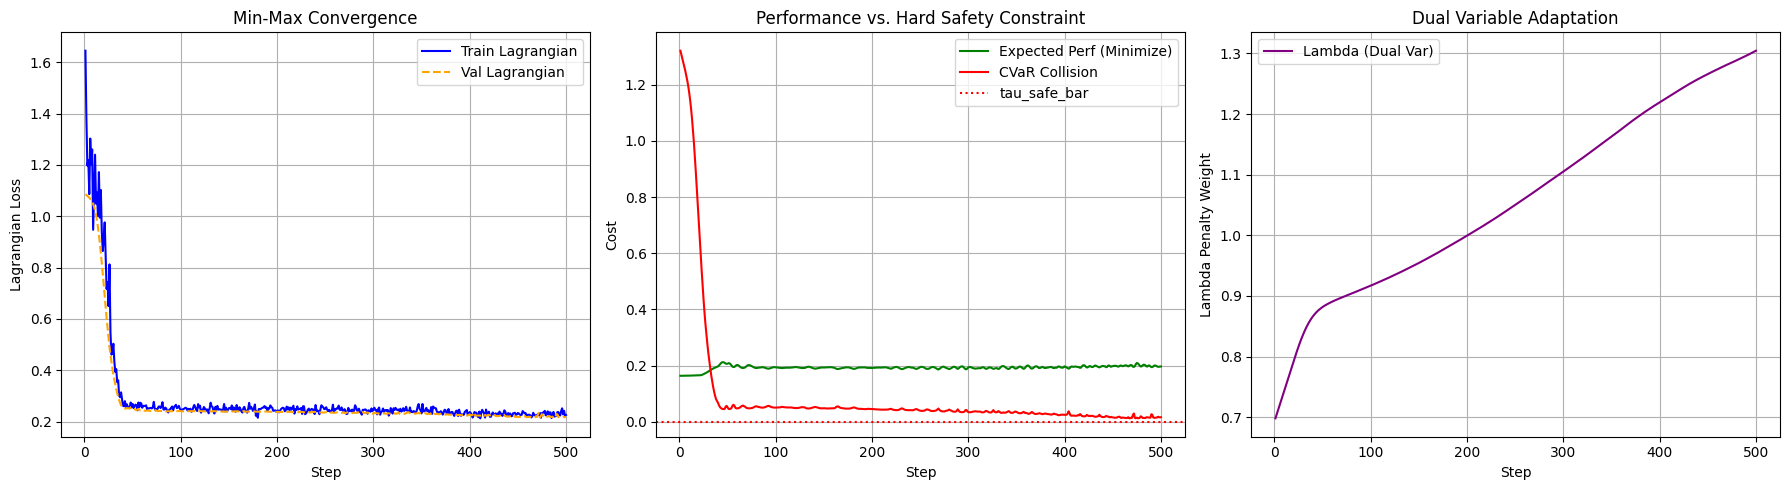

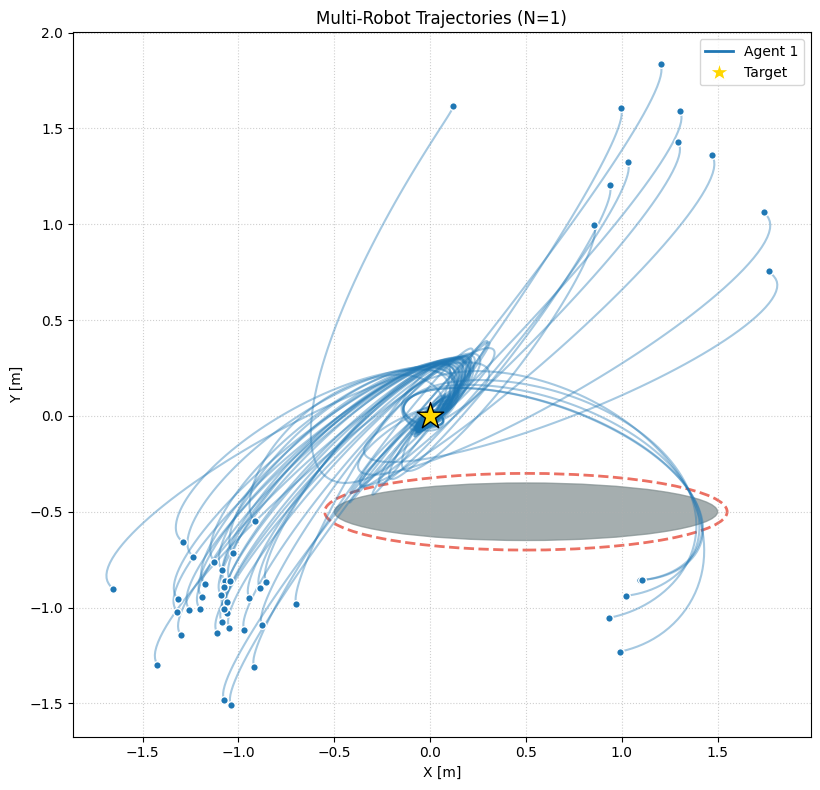

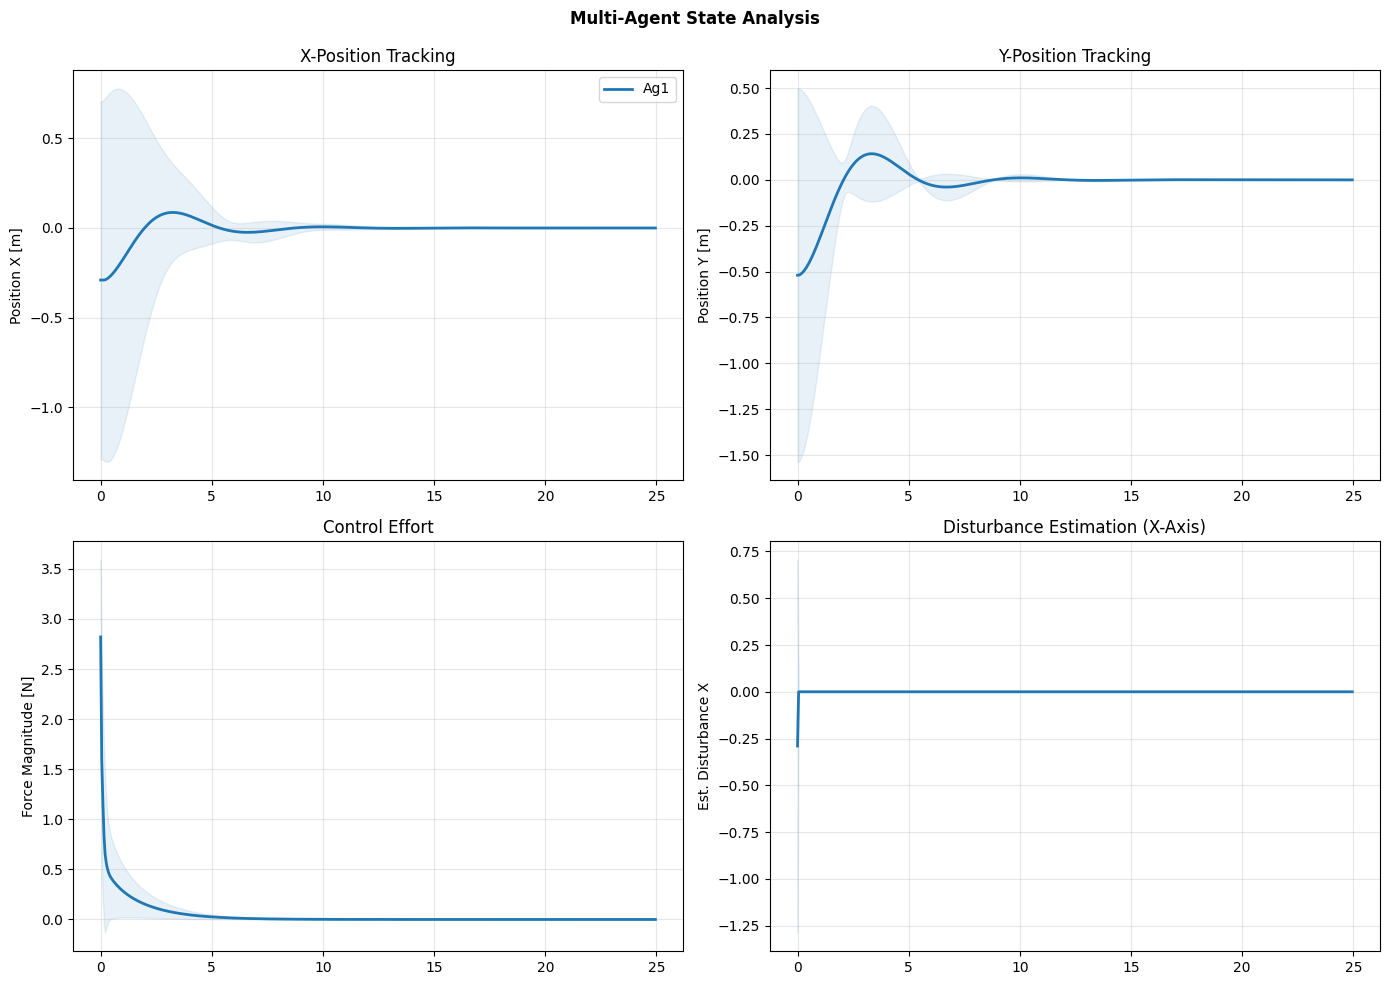

In [5]:
if len(val_lagrangians) == 0:
    raise RuntimeError("No logged validation points found. Run the training cell first.")

steps = range(log_interval, log_interval * (len(val_lagrangians) + 1), log_interval)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.plot(steps, train_lagrangians, label="Train Lagrangian", color="blue")
ax1.plot(steps, val_lagrangians, label="Val Lagrangian", color="orange", linestyle="--")
ax1.set_xlabel("Step")
ax1.set_ylabel("Lagrangian Loss")
ax1.set_title("Min-Max Convergence")
ax1.legend()
ax1.grid(True)

ax2.plot(steps, val_perfs, label="Expected Perf (Minimize)", color="green")
ax2.plot(steps, val_cvars, label="CVaR Collision", color="red")
ax2.axhline(y=tau_safe_bar, color="red", linestyle=":", label="tau_safe_bar")
ax2.set_xlabel("Step")
ax2.set_ylabel("Cost")
ax2.set_title("Performance vs. Hard Safety Constraint")
ax2.legend()
ax2.grid(True)

ax3.plot(steps, val_lambdas, label="Lambda (Dual Var)", color="purple")
ax3.set_xlabel("Step")
ax3.set_ylabel("Lambda Penalty Weight")
ax3.set_title("Dual Variable Adaptation")
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()

if last_traj_x_val is None:
    raise RuntimeError("Validation trajectories were not stored. Re-run the training cell.")

plot_pb_trajectories(
    traj_x=last_traj_x_val,
    traj_u=last_traj_u_val,
    traj_w_hat=last_traj_w_hat_val,
    x_target=x_target,
    obs_centers=obs_centers,
    obs_radii=obs_radii,
    obs_radii_safe=obs_radii_safe,
    dt=dt,
)

## Best-checkpoint test evaluation

Load the best saved Lagrangian model and evaluate on a fresh GMM test batch.

Missing keys while loading: ['x', 'init_x']
=== CVaR-constrained model test ===
Expected performance E[cx+cu] : 0.199852
Expected collision  E[coll]   : 0.002331


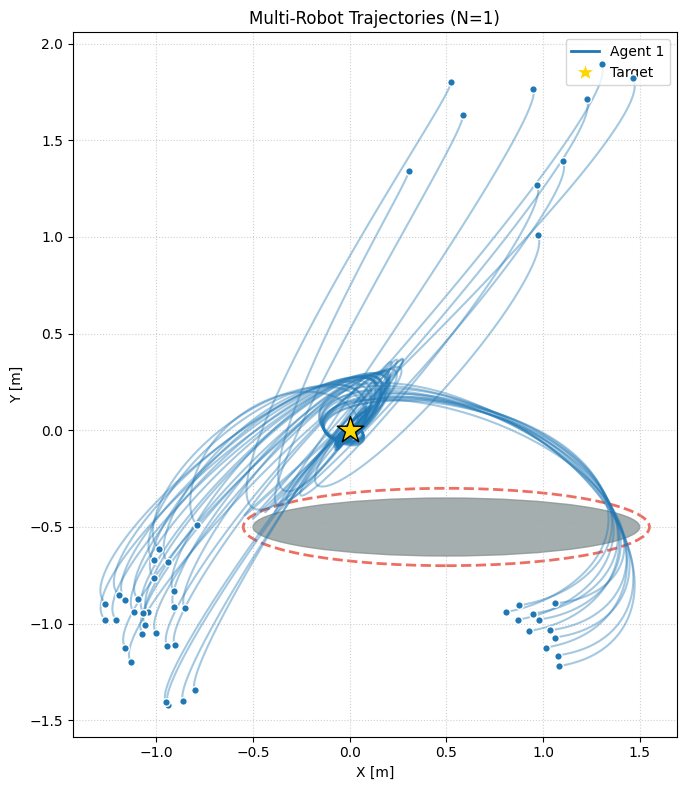

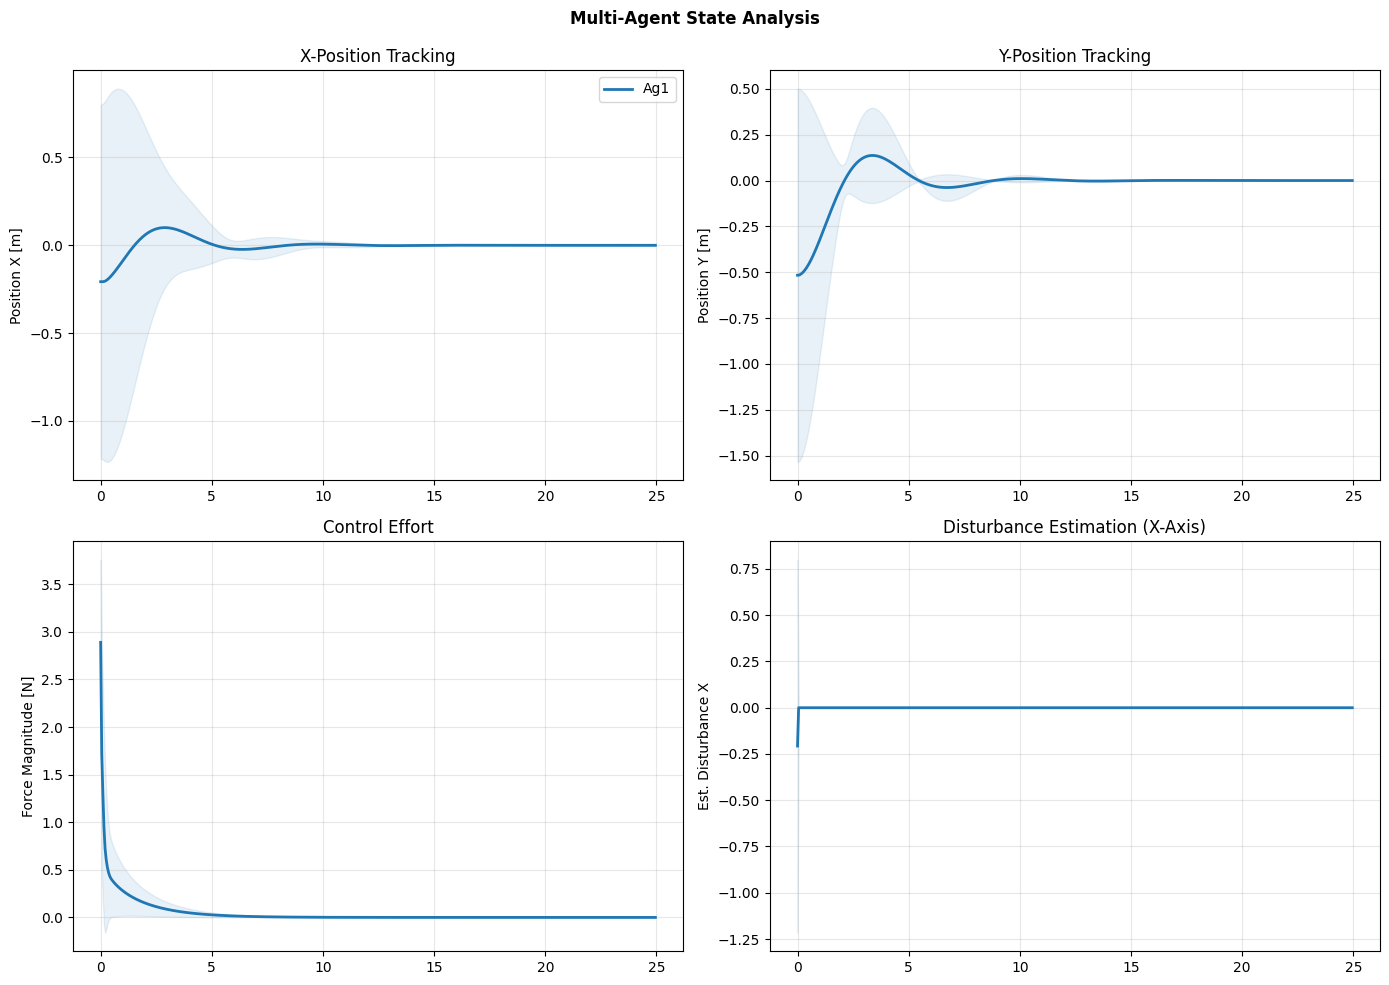

In [6]:
num_test_samples = 10000

# Rebuild model for clean checkpoint evaluation
ren_test = ContractiveREN(
    dim_in=state_dim * n_agents,
    dim_out=input_dim * n_agents,
    dim_internal=dim_internal,
    dim_nl=dim_nl,
    initialization_std=initialization_std,
).to(device)

pb_test = PBClosedLoop(ren_test, f_sim, f_nom).to(device)

# Load best checkpoint
ckpt = torch.load(checkpoint_path, map_location=device)
ren_state = ckpt["ren_state"] if "ren_state" in ckpt else ckpt

# Be robust to transient keys
transient_keys = {"x", "init_x"}
ren_state = {k: v for k, v in ren_state.items() if k not in transient_keys}
load_result = ren_test.load_state_dict(ren_state, strict=False)

if len(load_result.unexpected_keys) > 0:
    print("Unexpected keys while loading:", load_result.unexpected_keys)
if len(load_result.missing_keys) > 0:
    print("Missing keys while loading:", load_result.missing_keys)

pb_test.eval()

# Fresh GMM test batch
test_w = generate_random_batch(
    batch_size=num_test_samples,
    horizon=horizon,
    n_agents=n_agents,
    x0_centers=x0_centers,
    x0_stds=x0_stds,
    x0_probs=x0_probs,
    noise_std=noise_std,
    device=device,
)

with torch.no_grad():
    traj_x_test, traj_u_test, traj_w_hat_test = pb_test.run(test_w)
    _, cost_x_test, cost_u_test, cost_coll_test = metric(traj_x_test, traj_u_test)

    test_perf = cost_x_test.mean() + cost_u_test.mean()
    test_coll = cost_coll_test.mean()

print("=== CVaR-constrained model test ===")
print(f"Expected performance E[cx+cu] : {test_perf.item():.6f}")
print(f"Expected collision  E[coll]   : {test_coll.item():.6f}")

plot_pb_trajectories(
    traj_x=traj_x_test.detach().cpu(),
    traj_u=traj_u_test.detach().cpu(),
    traj_w_hat=traj_w_hat_test.detach().cpu(),
    x_target=x_target,
    obs_centers=obs_centers,
    obs_radii=obs_radii,
    obs_radii_safe=obs_radii_safe,
    dt=dt,
)

# Expected-performance training with expected-collision constraint

This block trains a separate model with objective:
- Minimize expected performance cost `E[c_x + c_u]`
- Subject to expected collision cost `E[c_coll] <= tau_safe_bar`

using a primal-dual Lagrangian update.

In [7]:
# Reproducibility seed for THIS model block only
seed_expected_model = 1234

torch.manual_seed(seed_expected_model)
np.random.seed(seed_expected_model)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed_expected_model)

# Deterministic backend behavior (for reproducible reruns of this block)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
try:
    torch.use_deterministic_algorithms(True)
except Exception:
    pass

print(f"Expected-collision constrained model seed set to {seed_expected_model}")

Expected-collision constrained model seed set to 1234


In [8]:
# Hyperparameters for expected-collision constrained training
# Use the same shared threshold as the CVaR experiment

num_training_steps_exp = num_training_steps
log_interval_exp = log_interval
batch_size_exp = batch_size
lr_exp = lr
max_grad_norm_exp = max_grad_norm

checkpoint_path_exp = "ren_expected_constraint_checkpoint.pt"

# Fixed validation batch (drawn after block-specific seed for deterministic reruns)
fixed_val_w_exp = generate_random_batch(
    batch_size=num_val_samples,
    horizon=horizon,
    n_agents=n_agents,
    x0_centers=x0_centers,
    x0_stds=x0_stds,
    x0_probs=x0_probs,
    noise_std=noise_std,
    device=device,
)

In [9]:
# Build a fresh model for expected-collision constrained training
ren_expected = ContractiveREN(
    dim_in=state_dim * n_agents,
    dim_out=input_dim * n_agents,
    dim_internal=dim_internal,
    dim_nl=dim_nl,
    initialization_std=initialization_std,
).to(device)

PB_closed_loop_sim_expected = PBClosedLoop(ren_expected, f_sim, f_nom).to(device)

metric_expected = PBLoss(
    x_target, Q, R, lambda_obs, obs_centers,
    obs_radii_safe=obs_radii_safe,
    n_agents=n_agents,
    track_mode=track_mode,
    coll_mode=coll_mode,
).to(device)

# Dual variable parameterization: lambda = softplus(pre_lambda) >= 0
pre_lambda_expected = torch.nn.Parameter(torch.tensor(0.0, device=device))

opt_primal_exp = torch.optim.Adam(PB_closed_loop_sim_expected.parameters(), lr=lr_exp)
opt_dual_exp = torch.optim.Adam([pre_lambda_expected], lr=lr_exp * 2.0, maximize=True)

train_lag_exp = []
val_lag_exp = []
val_perf_exp = []
val_coll_exp = []
val_lambda_exp = []

last_traj_x_val_exp = None
last_traj_u_val_exp = None
last_traj_w_hat_val_exp = None

best_val_lag_exp = float("inf")
print(f"Starting expected-collision constrained training on {device}...")
pbar_exp = tqdm(range(num_training_steps_exp), desc="Expected-Constraint Training")

for step in pbar_exp:
    PB_closed_loop_sim_expected.train()
    opt_primal_exp.zero_grad()
    opt_dual_exp.zero_grad()

    batch_w = generate_random_batch(
        batch_size=batch_size_exp,
        horizon=horizon,
        n_agents=n_agents,
        x0_centers=x0_centers,
        x0_stds=x0_stds,
        x0_probs=x0_probs,
        noise_std=noise_std,
        device=device,
    )

    traj_x_train, traj_u_train, traj_w_hat_train = PB_closed_loop_sim_expected.run(batch_w)
    _, cost_x_train, cost_u_train, cost_coll_train = metric_expected(traj_x_train, traj_u_train)

    expected_perf_train = cost_x_train.mean() + cost_u_train.mean()
    expected_coll_train = cost_coll_train.mean()
    lambda_dual_train = torch.nn.functional.softplus(pre_lambda_expected)
    lagrangian_train = expected_perf_train + lambda_dual_train * (expected_coll_train - tau_safe_bar)

    lagrangian_train.backward()
    torch.nn.utils.clip_grad_norm_(PB_closed_loop_sim_expected.parameters(), max_grad_norm_exp)
    opt_primal_exp.step()
    opt_dual_exp.step()

    if (step + 1) % log_interval_exp == 0:
        PB_closed_loop_sim_expected.eval()
        with torch.no_grad():
            traj_x_val, traj_u_val, traj_w_hat_val = PB_closed_loop_sim_expected.run(fixed_val_w_exp)
            _, cost_x_val, cost_u_val, cost_coll_val = metric_expected(traj_x_val, traj_u_val)

            expected_perf_val = cost_x_val.mean()
            expected_perf_val = expected_perf_val + cost_u_val.mean()
            expected_coll_val = cost_coll_val.mean()
            lambda_dual_val = torch.nn.functional.softplus(pre_lambda_expected)
            lagrangian_val = expected_perf_val + lambda_dual_val * (expected_coll_val - tau_safe_bar)

        last_traj_x_val_exp = traj_x_val.detach().cpu()
        last_traj_u_val_exp = traj_u_val.detach().cpu()
        last_traj_w_hat_val_exp = traj_w_hat_val.detach().cpu()

        lag_train_item = lagrangian_train.item()
        lag_val_item = lagrangian_val.item()
        perf_val_item = expected_perf_val.item()
        coll_val_item = expected_coll_val.item()
        lambda_val_item = lambda_dual_val.item()
        viol_val_item = coll_val_item - tau_safe_bar

        train_lag_exp.append(lag_train_item)
        val_lag_exp.append(lag_val_item)
        val_perf_exp.append(perf_val_item)
        val_coll_exp.append(coll_val_item)
        val_lambda_exp.append(lambda_val_item)

        improved = lag_val_item < best_val_lag_exp
        if improved:
            best_val_lag_exp = lag_val_item
            torch.save(
                {
                    "ren_state": ren_expected.state_dict(),
                    "opt_primal_state": opt_primal_exp.state_dict(),
                    "opt_dual_state": opt_dual_exp.state_dict(),
                    "pre_lambda": pre_lambda_expected.item(),
                    "step": step,
                    "val_lagrangian": best_val_lag_exp,
                    "val_perf": perf_val_item,
                    "val_expected_collision": coll_val_item,
                    "val_violation": viol_val_item,
                    "constraint": tau_safe_bar,
                },
                checkpoint_path_exp,
            )
        pbar_exp.set_postfix({
            "Val Perf": f"{perf_val_item:.3f}",
            "Val E[Coll]": f"{coll_val_item:.4f}",
            "Viol": f"{viol_val_item:.4f}",
            "Lambda": f"{lambda_val_item:.3f}",
            "Best Val Lag": f"{best_val_lag_exp:.3f}",
        })

pbar_exp.close()

print(f"Training complete (expected-collision constrained). Best val lagrangian: {best_val_lag_exp:.4f}")
print(f"Best checkpoint saved to: {checkpoint_path_exp}")

Starting expected-collision constrained training on cpu...


Expected-Constraint Training: 100%|██████████| 500/500 [03:24<00:00,  2.45it/s, Val Perf=0.130, Val E[Coll]=0.0105, Viol=0.0105, Lambda=0.947, Best Val Lag=0.139]

Training complete (expected-collision constrained). Best val lagrangian: 0.1394
Best checkpoint saved to: ren_expected_constraint_checkpoint.pt


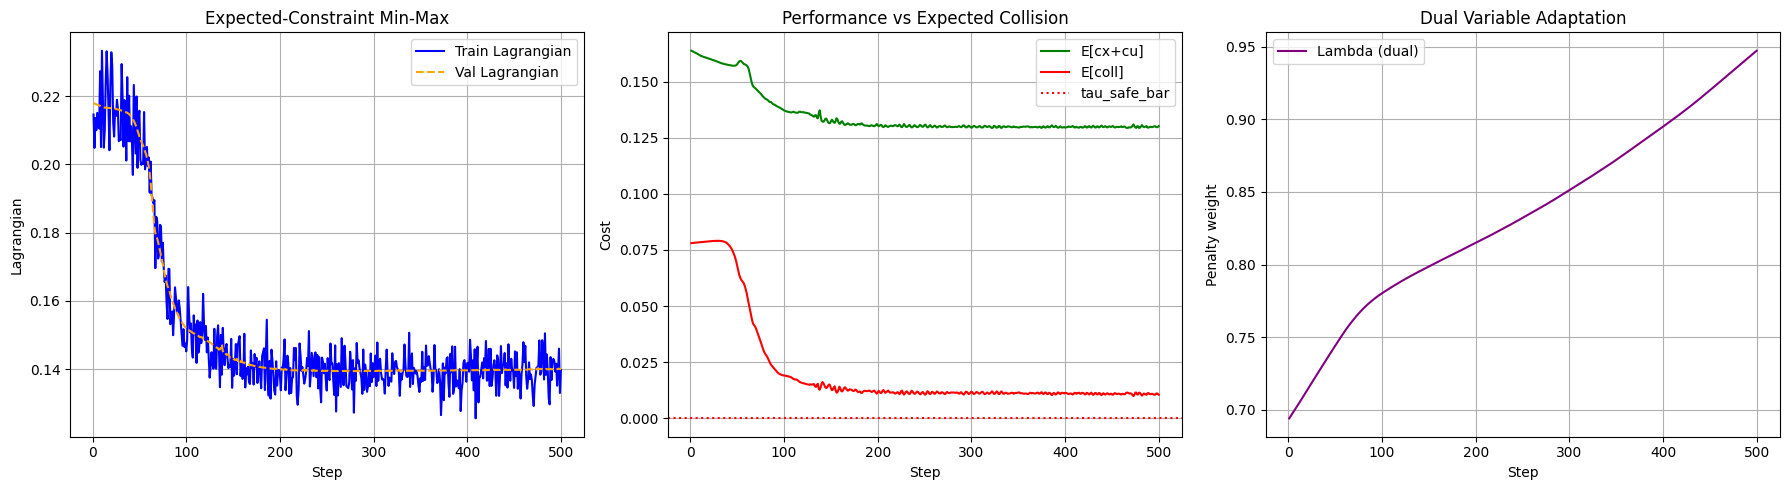

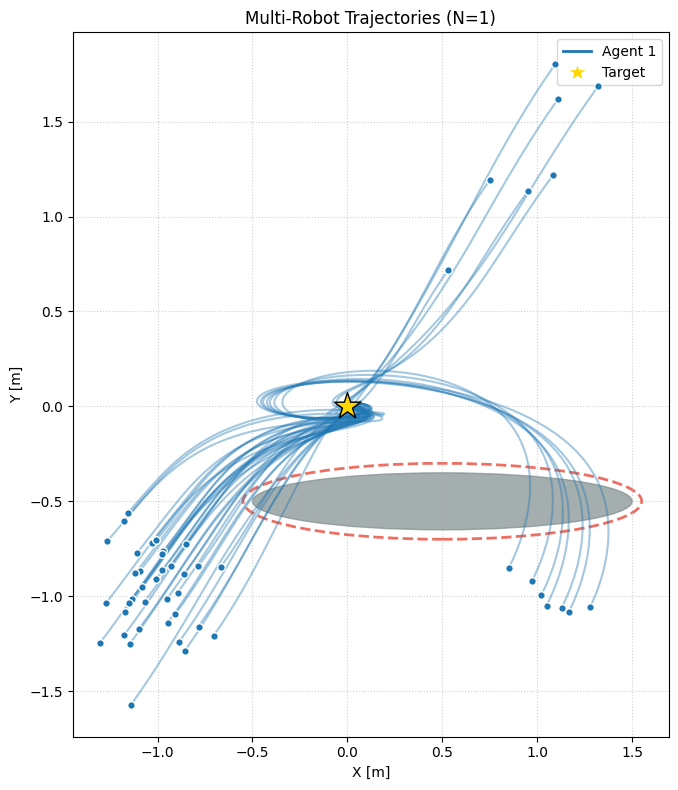

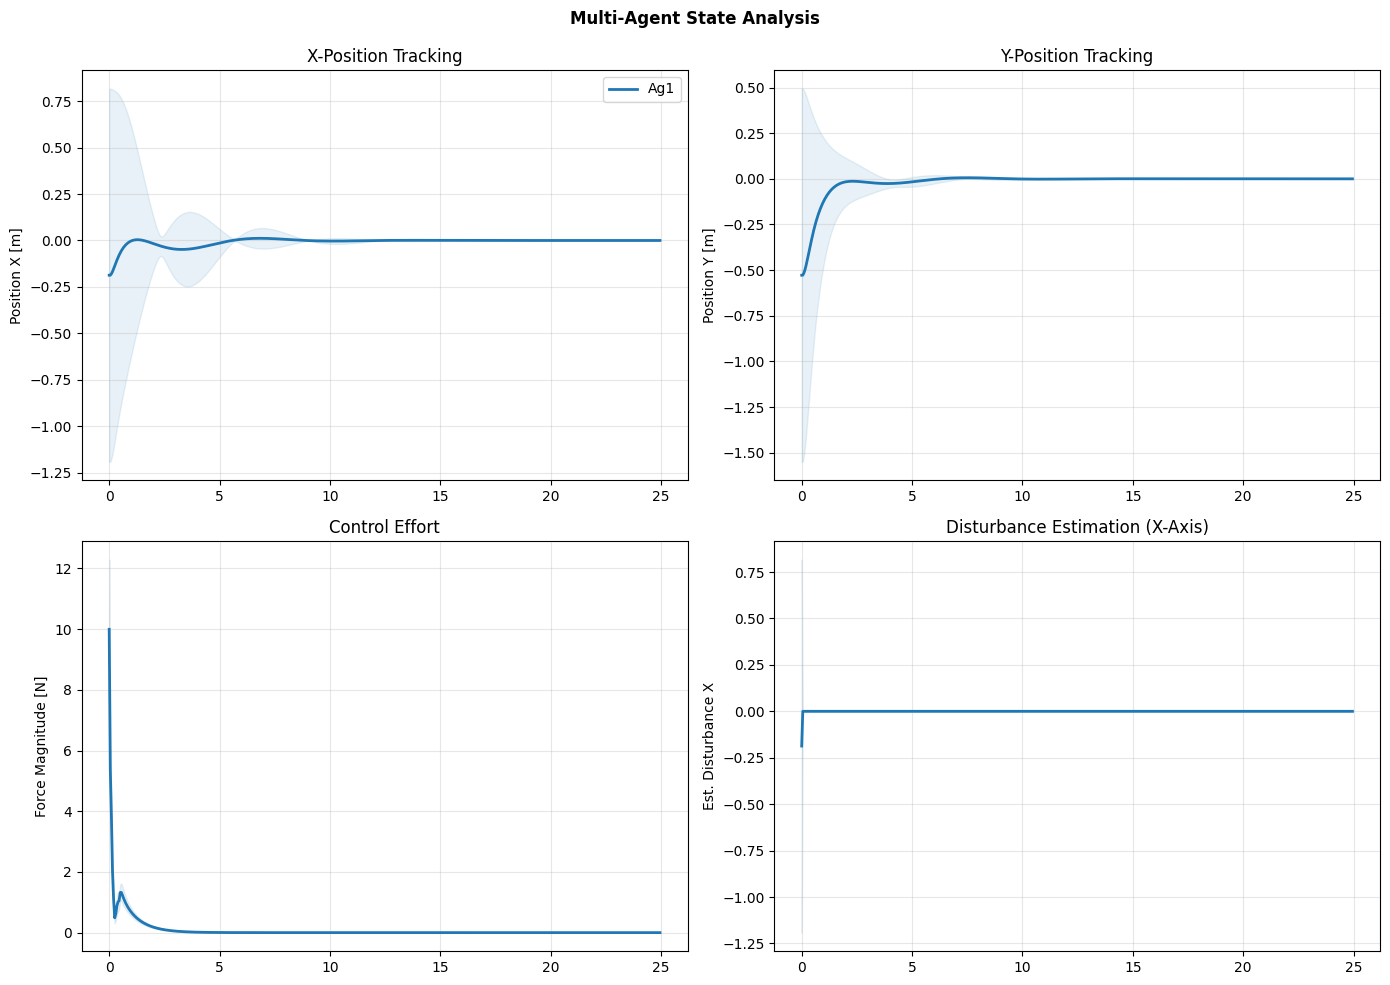

In [10]:
if len(val_lag_exp) == 0:
    raise RuntimeError("No logged points for expected-collision constrained training. Run training cell first.")

steps_exp = range(log_interval_exp, log_interval_exp * (len(val_lag_exp) + 1), log_interval_exp)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.plot(steps_exp, train_lag_exp, label="Train Lagrangian", color="blue")
ax1.plot(steps_exp, val_lag_exp, label="Val Lagrangian", color="orange", linestyle="--")
ax1.set_xlabel("Step")
ax1.set_ylabel("Lagrangian")
ax1.set_title("Expected-Constraint Min-Max")
ax1.legend()
ax1.grid(True)

ax2.plot(steps_exp, val_perf_exp, label="E[cx+cu]", color="green")
ax2.plot(steps_exp, val_coll_exp, label="E[coll]", color="red")
ax2.axhline(y=tau_safe_bar, color="red", linestyle=":", label="tau_safe_bar")
ax2.set_xlabel("Step")
ax2.set_ylabel("Cost")
ax2.set_title("Performance vs Expected Collision")
ax2.legend()
ax2.grid(True)

ax3.plot(steps_exp, val_lambda_exp, label="Lambda (dual)", color="purple")
ax3.set_xlabel("Step")
ax3.set_ylabel("Penalty weight")
ax3.set_title("Dual Variable Adaptation")
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()

if last_traj_x_val_exp is not None:
    plot_pb_trajectories(
        traj_x=last_traj_x_val_exp,
        traj_u=last_traj_u_val_exp,
        traj_w_hat=last_traj_w_hat_val_exp,
        x_target=x_target,
        obs_centers=obs_centers,
        obs_radii=obs_radii,
        obs_radii_safe=obs_radii_safe,
        dt=dt,
    )

## Best-checkpoint test evaluation (expected-collision constraint)

Load the best saved expected-constraint model and evaluate on a fresh GMM test batch with the same shared constraint threshold.

Missing keys while loading: ['x', 'init_x']
=== Expected-collision-constrained model test ===
Expected performance E[cx+cu] : 0.129264
Expected collision  E[coll]   : 0.011010


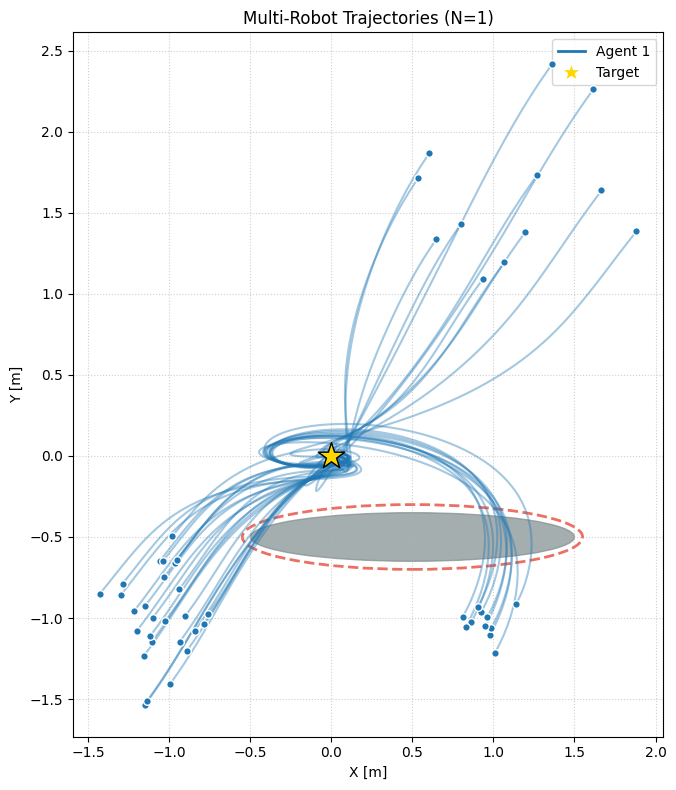

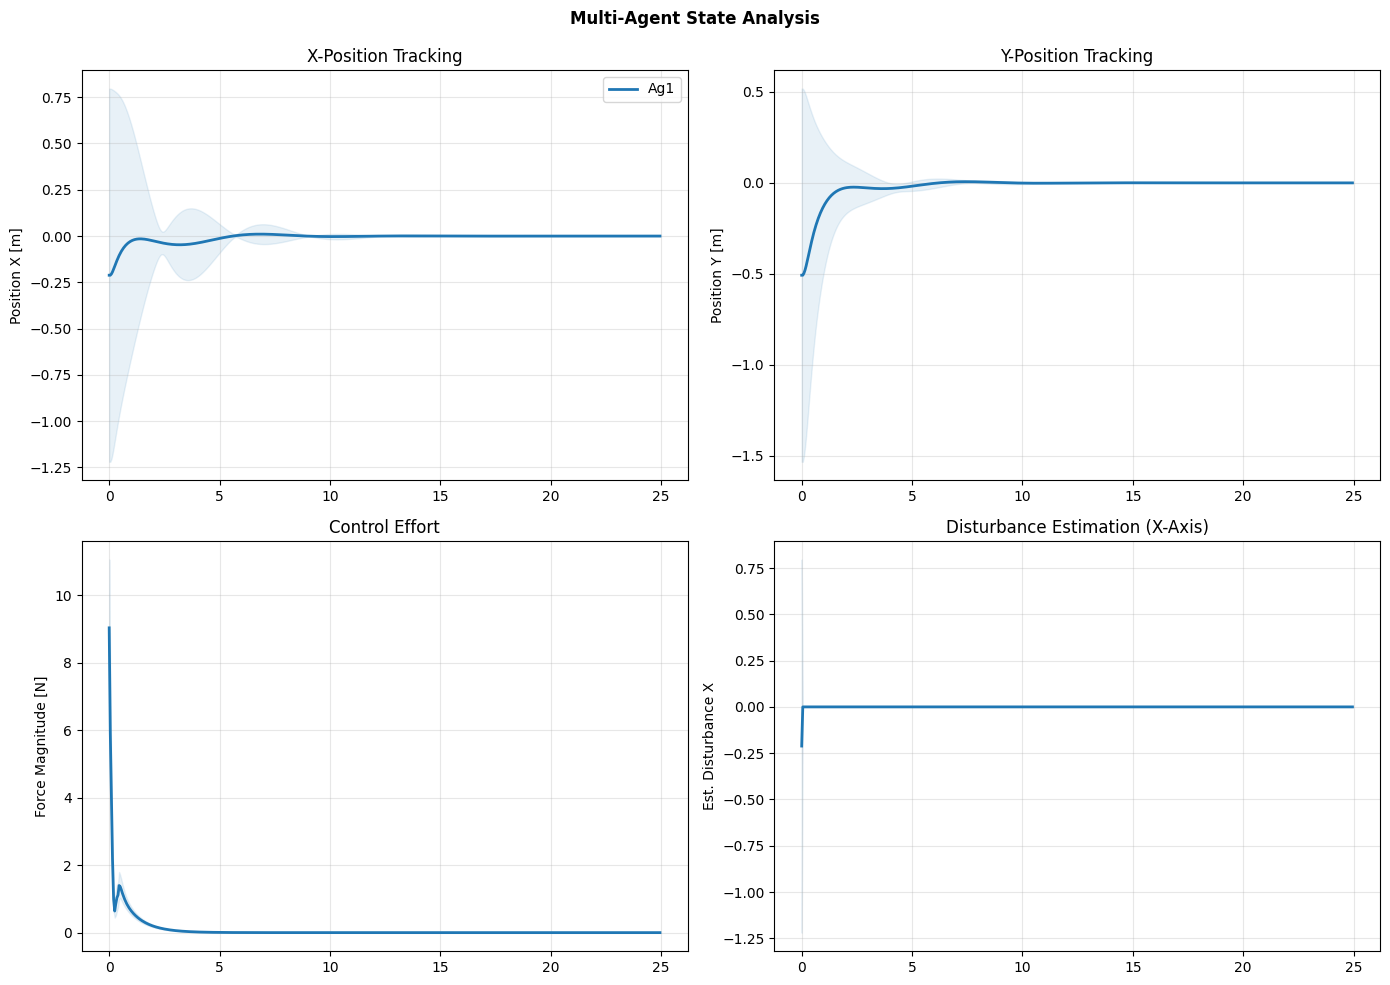

In [11]:
num_test_samples_exp = 10000

# Rebuild model for clean checkpoint evaluation
ren_test_exp = ContractiveREN(
    dim_in=state_dim * n_agents,
    dim_out=input_dim * n_agents,
    dim_internal=dim_internal,
    dim_nl=dim_nl,
    initialization_std=initialization_std,
).to(device)

pb_test_exp = PBClosedLoop(ren_test_exp, f_sim, f_nom).to(device)

# Load best checkpoint from expected-collision constrained training
ckpt_exp = torch.load(checkpoint_path_exp, map_location=device)
ren_state_exp = ckpt_exp["ren_state"] if "ren_state" in ckpt_exp else ckpt_exp
transient_keys_exp = {"x", "init_x"}
ren_state_exp = {k: v for k, v in ren_state_exp.items() if k not in transient_keys_exp}
load_result_exp = ren_test_exp.load_state_dict(ren_state_exp, strict=False)

if len(load_result_exp.unexpected_keys) > 0:
    print("Unexpected keys while loading:", load_result_exp.unexpected_keys)
if len(load_result_exp.missing_keys) > 0:
    print("Missing keys while loading:", load_result_exp.missing_keys)

pb_test_exp.eval()

# Fresh GMM test batch
test_w_exp = generate_random_batch(
    batch_size=num_test_samples_exp,
    horizon=horizon,
    n_agents=n_agents,
    x0_centers=x0_centers,
    x0_stds=x0_stds,
    x0_probs=x0_probs,
    noise_std=noise_std,
    device=device,
)

with torch.no_grad():
    traj_x_test_exp, traj_u_test_exp, traj_w_hat_test_exp = pb_test_exp.run(test_w_exp)
    _, cost_x_test_exp, cost_u_test_exp, cost_coll_test_exp = metric_expected(traj_x_test_exp, traj_u_test_exp)

    test_perf_exp = cost_x_test_exp.mean() + cost_u_test_exp.mean()
    test_coll_exp = cost_coll_test_exp.mean()

print("=== Expected-collision-constrained model test ===")
print(f"Expected performance E[cx+cu] : {test_perf_exp.item():.6f}")
print(f"Expected collision  E[coll]   : {test_coll_exp.item():.6f}")

plot_pb_trajectories(
    traj_x=traj_x_test_exp.detach().cpu(),
    traj_u=traj_u_test_exp.detach().cpu(),
    traj_w_hat=traj_w_hat_test_exp.detach().cpu(),
    x_target=x_target,
    obs_centers=obs_centers,
    obs_radii=obs_radii,
    obs_radii_safe=obs_radii_safe,
    dt=dt,
)